In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("cor_da_justica.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7406 entries, 0 to 7405
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7406 non-null   int64  
 1   ementa                 7107 non-null   object 
 2   ementaDetalhada        444 non-null    object 
 3   keywords               3877 non-null   object 
 4   uris.uriAutores        7406 non-null   object 
 5   uris.uriPropPrincipal  1679 non-null   object 
 6   uris.uriUltimoRelator  2574 non-null   object 
 7   nome                   7406 non-null   object 
 8   cpf                    7406 non-null   int64  
 9   foto                   7406 non-null   object 
 10  sexo                   7406 non-null   object 
 11  nascimento             7406 non-null   object 
 12  local_nascimento       7406 non-null   object 
 13  escolaridade           7234 non-null   object 
 14  orgão                  0 non-null      float64
 15  emen

In [8]:
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "ementaDetalhada", "ementa.1", "keywords.1", "cpf", ]

In [9]:
df = df.drop(columns=remover_colunas)

In [10]:
df

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
0,Dispõe sobre a obrigatoriedade de fotografia n...,"Alteração, Lei do Processamento Eletrônico do ...",CARLOS FREDERICO THEODORO NADER,M,1965-09-21,Barra Mansa - RJ,Superior,NaN,NaN,NaN,#NE
1,Garante ao acertador de qualquer tipo de jogo ...,"Garantia, omissão, identificação, ganhador, lo...",ANDRES NAVARRO SANCHEZ,M,1963-12-24,Limeira - SP,Ensino Fundamental,NaN,Aguardando Parecer,Projeto de Lei,BRANCA
2,Dispõe sobre a obrigatoriedade das prestadoras...,"Obrigatoriedade, concessionária, telefone celu...",FRANCISCO RODRIGUES DE ALENCAR FILHO,M,1949-10-19,Rio de Janeiro - RJ,Mestrado,NaN,Aguardando Parecer,Projeto de Lei,#NE
3,Institui o dia 02 de julho como data histórica...,"Criação, Dia Nacional da Independência do Bras...",DOUGLAS DE PAULO VIEGAS,M,1979-06-19,São Paulo - SP,NaN,NaN,NaN,NaN,PARDA
4,Altera o inciso I do § 1º do art. 68 da Lei nº...,"Alteração, Nova Lei de Patentes, licenciament...",CÁSSIO MURILO GALDINO DE ARAÚJO,M,1980-07-02,Pocinhos - PB,Superior,NaN,NaN,NaN,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...
7401,Institui o Programa de Aceleração da Transição...,NaN,AFONSO ANTUNES DA MOTTA,M,1950-01-08,Porto Alegre - RS,Superior,NaN,NaN,NaN,#NE#
7402,Destaque de Emenda - PL 3/2024,NaN,ELMAR JOSE VIEIRA NASCIMENTO,M,1970-07-06,Campo Formoso - BA,Pós-Graduação,NaN,NaN,NaN,PARDA
7403,Requerimento de Votação Nominal-Destaque de Em...,NaN,ELMAR JOSE VIEIRA NASCIMENTO,M,1970-07-06,Campo Formoso - BA,Pós-Graduação,NaN,NaN,NaN,PARDA
7404,Destaque de Emenda - PL 327/2021,NaN,GERVÁSIO AGRIPINO MAIA,M,1975-04-14,São Paulo - SP,Superior,NaN,NaN,NaN,#NE


In [11]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

C:\Users\alexa\AppData\Local\Temp\ipykernel_16436\1803048690.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["

In [12]:
situacao = df["situacao"].value_counts().reset_index()

In [13]:
situacao

,situacao,count
0,RECUSADO,5866
1,TRAMITANDO,793
2,AGUARDANDO,747


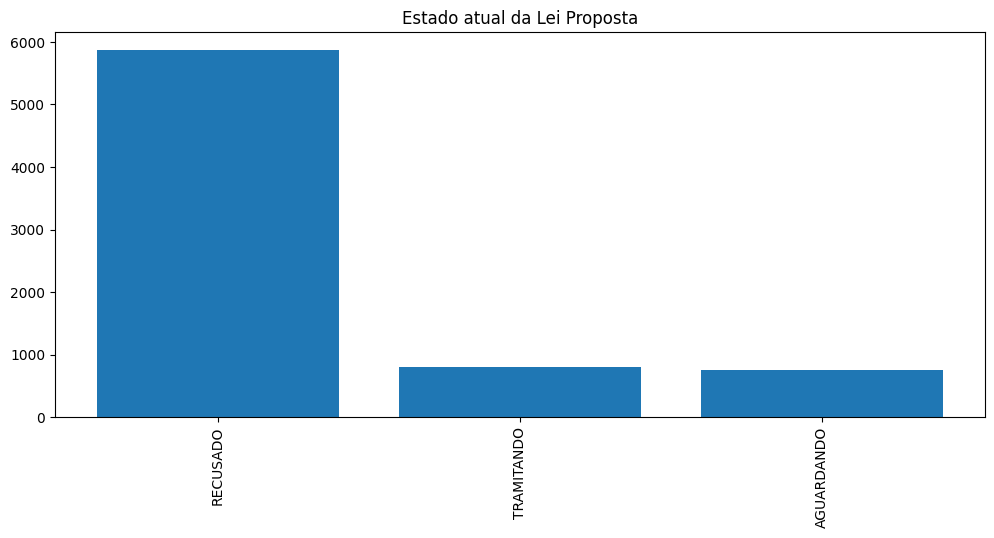

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.bar(situacao["situacao"], height=situacao["count"],)
plt.xticks(rotation=90)
# plt.bar()
ax.set_title("Estado atual da Lei Proposta")
plt.show()

In [15]:
sexo = df['sexo'].value_counts().reset_index()

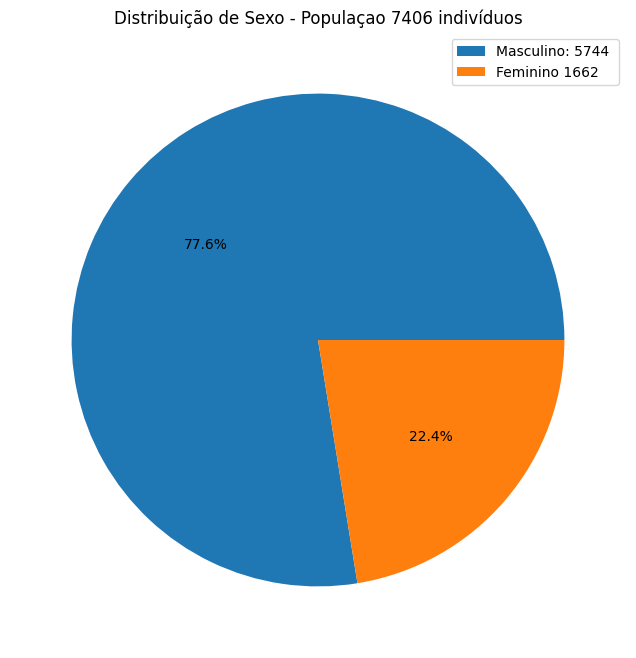

In [16]:
fg, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.pie(sexo["count"], autopct="%.1f%%")
ax.set_title(
    f"Distribuição de Sexo - Populaçao {df['sexo'].count()} indivíduos")
ax.legend([f"Masculino: {sexo['count'][0]} ", f"Feminino {sexo['count'][1]}"])
plt.show()

In [17]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

In [18]:
df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA") ] = "OUTROS"

C:\Users\alexa\AppData\Local\Temp\ipykernel_16436\1879082908.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["cor"].loc[(df["cor"] == "AMARELA") | (
C:\Users\alexa\AppData\Local\Temp\ipykernel_16436\1879082908.py:1: SettingWithCopyWar

In [19]:
cor = df["cor"].value_counts().reset_index()

In [20]:
cor["cor"].unique()
cor

,cor,count
0,BRANCA,2212
1,OUTROS,1166


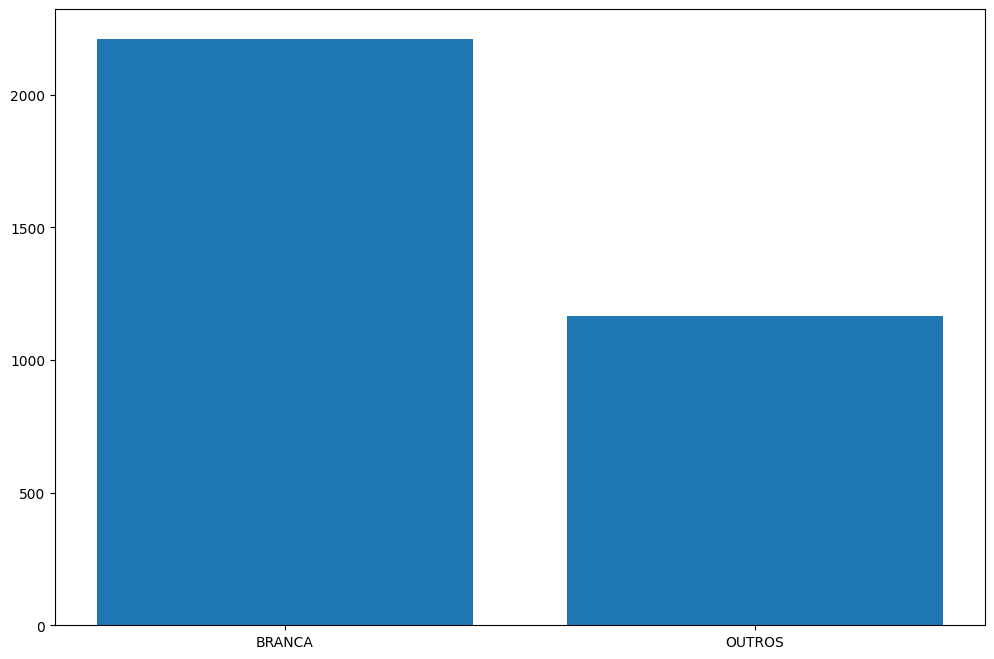

In [21]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [22]:
df.iloc[10:50]

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
10,Dispõe sobre a reintegração no emprego dos fun...,"Garantia, reintegração, retorno, emprego, ex-f...",FERNANDO MONTEIRO DE ALBUQUERQUE,M,1976-09-17,Recife - PE,Superior,NaN,RECUSADO,NaN,BRANCA
11,"Altera as Leis nºs 8.429, de 2 de junho de 19...","Alteração, Lei da Improbidade Administrativa, ...",KIM PATROCA KATAGUIRI,M,1996-01-28,Salto - SP,Superior Incompleto,NaN,RECUSADO,NaN,OUTROS
12,Autoriza o Poder Executivo a criar o Programa ...,"Autorização, Executivo, criação, Programa de I...",SAMIA DE SOUZA BOMFIM,F,1989-08-22,Presidente Prudente - SP,Superior,NaN,RECUSADO,NaN,BRANCA
13,"Altera a Lei nº 9.656, de 3 de junho de 1998, ...","Alteração, Lei dos Planos de Saúde, cobertura,...",HILDELIS SILVA DUARTE JUNIOR,M,1986-09-15,Rio de Janeiro - RJ,Doutorado Incompleto,NaN,RECUSADO,NaN,BRANCA
14,Dispõe sobre o Estatuto do Nascituro e dá outr...,"Criação, Estatuto do Nascituro, proteção, nasc...",PRISCILA BEZERRA DA COSTA,F,1984-09-12,Fortaleza - CE,Superior,NaN,RECUSADO,NaN,OUTROS
15,"Altera a Lei nº 5.991, de 17 de setembro de 19...","Alteração, Lei de Controle Sanitário de Medica...",ALESSANDRA HABER CARVALHO SANTOS,F,1988-09-15,Belém - PA,Superior,NaN,RECUSADO,NaN,BRANCA
16,Dá nova redação ao § 4º do art. 201 da Constit...,"Previdência Social, vinculação, reajuste, valo...",SAMIA DE SOUZA BOMFIM,F,1989-08-22,Presidente Prudente - SP,Superior,NaN,RECUSADO,NaN,BRANCA
17,"Revoga a Lei Complementar nº 110, de 29 de jun...","Revogação, Lei de Atualização Monetária do FG...",RODRIGO SANTANA VALADARES,M,1989-08-06,Aracaju - SE,Superior,NaN,RECUSADO,NaN,BRANCA
18,"Dispõe sobre a prática de tatuagem e ""piercing"".","Funcionamento, estabelecimento comercial, prof...",LUIZ EDUARDO CARNEIRO DA SILVA DE SOUZA LIMA,M,1977-12-10,Rio de Janeiro - RJ,Superior,NaN,RECUSADO,NaN,OUTROS
19,Dispõe sobre a obrigatoriedade de banheiros pú...,"Obrigatoriedade, agência bancária, instalação,...",DANIELA MOTE DE SOUZA CARNEIRO,F,1976-02-10,Rio de Janeiro - RJ,Pós-Graduação,NaN,RECUSADO,NaN,BRANCA


In [23]:
from nltk.stem import PorterStemmer
import nltk
from nltk.corpus import stopwords

# stopwords = nltk.download('stopwords')
stemmer = PorterStemmer()

In [24]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

## TF - IDF


In [25]:

from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()

In [26]:
vocab

array(['00', '000', '0001', ..., 'única', 'único', 'útero'], dtype=object)

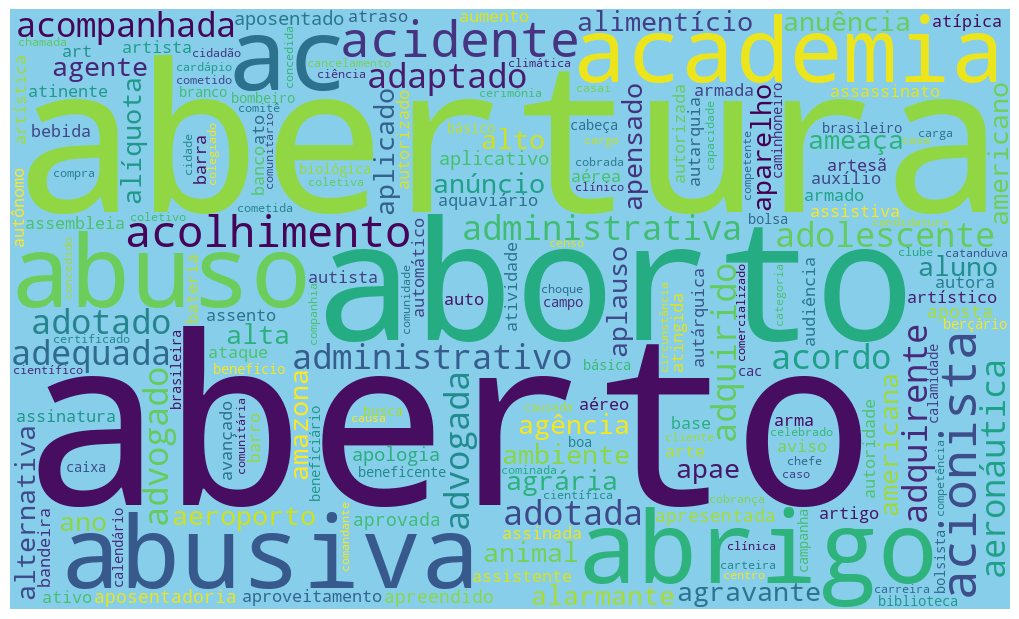

In [27]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud
vocab = ' '.join(vocab)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='skyblue',
    min_font_size=10).generate(vocab)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [28]:
X

<3250x8509 sparse matrix of type '<class 'numpy.float64'>'
	with 54421 stored elements in Compressed Sparse Row format>

In [29]:
df["cor"]

0       BRANCA
1       OUTROS
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
3245    OUTROS
3246    BRANCA
3247    BRANCA
3248    OUTROS
3249    OUTROS
Name: cor, Length: 3250, dtype: object

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [31]:
df["cor"]

0       0
1       1
2       0
3       0
4       0
       ..
3245    1
3246    0
3247    0
3248    1
3249    1
Name: cor, Length: 3250, dtype: int32

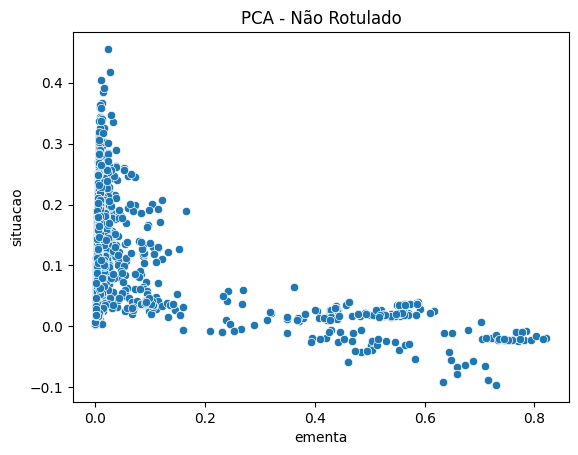

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

# Instantiate the PCA model with the desired number of components
# In this example, we set n_components to 2 for 2D visualization
pca = TruncatedSVD(n_components=2)

# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao',])
df_pca["target"] = df["cor"].reset_index(drop=True)


# Visualize the transformed data

sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

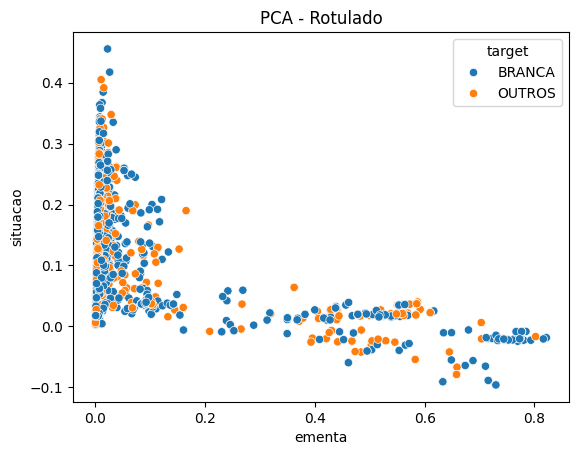

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

# Instantiate the PCA model with the desired number of components
# In this example, we set n_components to 2 for 2D visualization
pca = TruncatedSVD(n_components=2)

# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])


df_pca["target"] = df["cor"].reset_index(drop=True)
y_map = {0: 'BRANCA', 1: "OUTROS"}


df_pca["target"] = df["cor"].map(y_map)

# Visualize the transformed data

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

# Treinar Modelo


In [34]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [35]:
X_train

<2275x8509 sparse matrix of type '<class 'numpy.float64'>'
	with 38450 stored elements in Compressed Sparse Row format>

In [36]:
# Creating a function to display model results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", "Outros"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

# Logistic Regression


In [37]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LogisticRegression(
    random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=100, tol=0.001)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.std())

Cross-Validation Results: [0.6539741  0.62623008 0.64023497 0.63109031 0.66550672]
Mean F1 Score: 0.014538709723762356


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       629
           1       0.56      0.44      0.50       346

    accuracy                           0.68       975
   macro avg       0.65      0.63      0.63       975
weighted avg       0.67      0.68      0.67       975



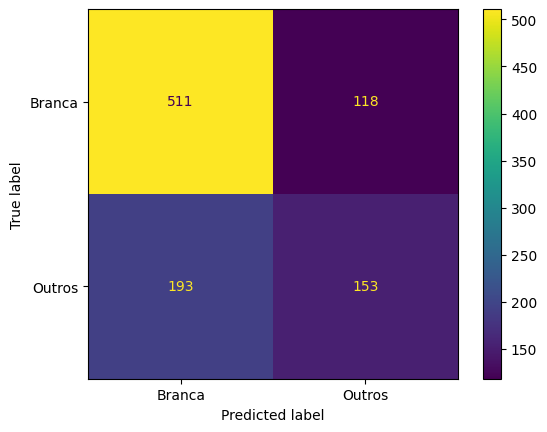

In [38]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier


In [39]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = SGDClassifier(random_state=42, alpha=0.0001, )

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.65701573 0.63141078 0.63249551 0.6482489  0.66434241]
Mean F1 Score: 0.6467026667019115


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       629
           1       0.55      0.46      0.50       346

    accuracy                           0.67       975
   macro avg       0.64      0.63      0.63       975
weighted avg       0.66      0.67      0.67       975



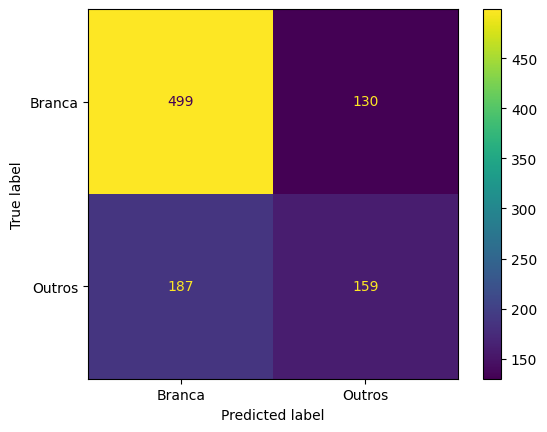

In [40]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# KNeighbors Classifier


In [41]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
# You can adjust the number of neighbors
model = KNeighborsClassifier(
    n_neighbors=100, weights="distance", algorithm="auto", leaf_size=50, p=2)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro',)
# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.std())

Cross-Validation Results: [0.55503561 0.551568   0.60141509 0.56403978 0.58722838]
Mean F1 Score: 0.019316686048403923


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.69      0.95      0.80       629
           1       0.69      0.21      0.32       346

    accuracy                           0.69       975
   macro avg       0.69      0.58      0.56       975
weighted avg       0.69      0.69      0.63       975



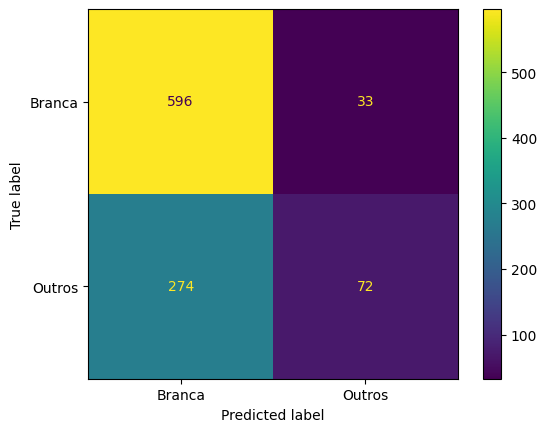

In [42]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - KNN", y_test, y_pred)

# SVC


In [43]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LinearSVC(penalty="l2", loss='squared_hinge',
                  tol=0.001, C=10, multi_class='ovr', dual=True)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.std())

Cross-Validation Results: [0.65929235 0.62552854 0.6348304  0.64807432 0.66495221]
Mean F1 Score: 0.014714496633853831


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       629
           1       0.54      0.48      0.51       346

    accuracy                           0.67       975
   macro avg       0.64      0.63      0.63       975
weighted avg       0.66      0.67      0.67       975



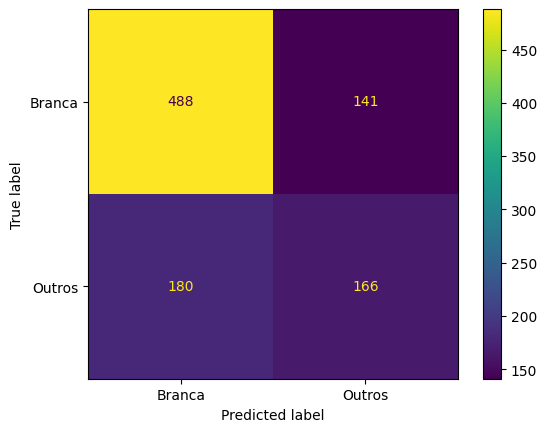

In [44]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest


In [45]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.3)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.64733258 0.62955927 0.65458428 0.67589669 0.63899353]
Mean F1 Score: 0.6492732683448665


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.71      0.89      0.79       629
           1       0.63      0.35      0.45       346

    accuracy                           0.70       975
   macro avg       0.67      0.62      0.62       975
weighted avg       0.68      0.70      0.67       975



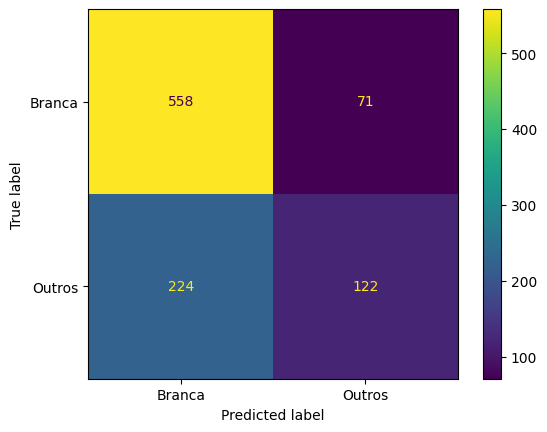

In [46]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

In [47]:
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))


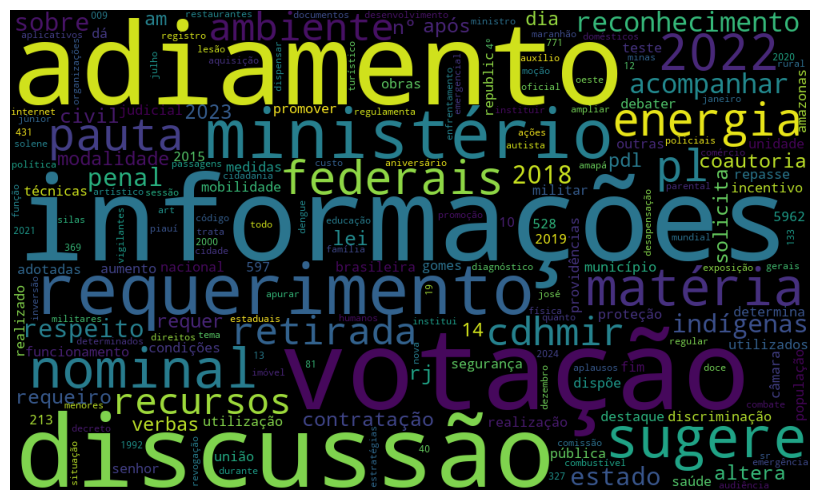

In [48]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

model.fit(X_train, y_train)
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

# Decision Tree


In [49]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Create the decision tree classifier
model = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')

# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

# Fit the decision tree classifier on the entire dataset
# model.fit(X, y)
# Plot the decision tree
# plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
# plot_tree(model,  feature_names=vocab.split(), class_names=["Branca", "Outros"], filled=True)

# plt.show()


Cross-Validation Results: [0.61325444 0.61075181 0.6221729  0.6349953  0.63476833]
Mean F1 Score: 0.6231885540690456


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       629
           1       0.55      0.34      0.42       346

    accuracy                           0.67       975
   macro avg       0.62      0.59      0.59       975
weighted avg       0.64      0.67      0.64       975



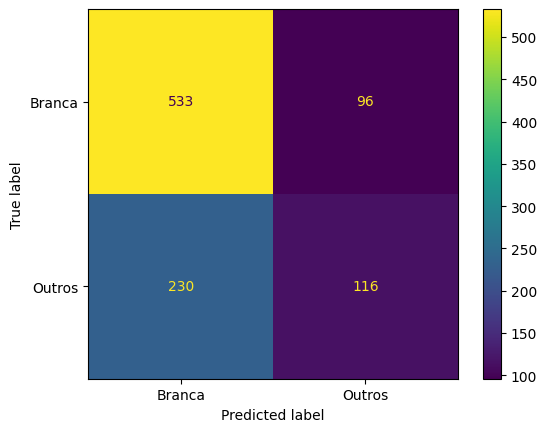

In [50]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)